#### Student Name: Vivian
#### Student ID: A17442498

# Assignment 9

### GAN, chroma (MIDI) and pix2pix

Instructions: 

* This notebook is an interactive assignment; please read and follow the instructions in each cell. 

* Cells that require your input (in the form of code or written response) will have 'Question #' above.

* After completing the assignment, please submit this notebook and printout as a PDF.


In this notebook we explore a style transfer application that tries to change the musical texture of a piece while maintaining the harmonic structure. In order to do so we train a pix2pix type of model that learns the relations between chroma and the musical texture (distribution of notes). For this purpose we extract chroma from MIDI data and learn a generator that complements the notes from a given texture. You can think about this as something similar to pix2pix that learns completion of image textures from a sketch that was mentioned in class. In the image GAN the contours for training are generated using an edge detection on a complete image.

# 1. Imports and Loading Data
Before running, please make sure to upload the following to your python directory
- reverse_pianoroll.py
- convert.py
- Classical_Music_Midi.zip and unzip it

In [1]:
import pretty_midi
import numpy as np

def reverse_pianoroll(pianoroll, fs=100, program=0, velocity=100):
    """
    Convert a piano-roll matrix (shape: 128 x T) into a PrettyMIDI object.
    pianoroll: numpy array of activations (can be binary or continuous)
    fs: frames per second (time resolution)
    """
    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=program)
    active = pianoroll > 0.5  # threshold; adjust if your data is already binary

    for pitch in range(pianoroll.shape[0]):
        is_on = False
        start_time = 0.0
        for frame in range(pianoroll.shape[1]):
            t = frame / fs
            if active[pitch, frame] and not is_on:
                is_on = True
                start_time = t
            elif not active[pitch, frame] and is_on:
                end_time = t
                note = pretty_midi.Note(velocity=velocity, pitch=pitch,
                                        start=start_time, end=end_time)
                instrument.notes.append(note)
                is_on = False
        if is_on:  # lingering note till end
            end_time = pianoroll.shape[1] / fs
            note = pretty_midi.Note(velocity=velocity, pitch=pitch,
                                    start=start_time, end=end_time)
            instrument.notes.append(note)

    pm.instruments.append(instrument)
    return pm

%pip install convert
import convert
import librosa

c:\Users\vivia\OneDrive\Documents\GitHub\ML4Music-HW\.venv\lib\site-packages\pretty_midi\instrument.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import sys

In [3]:
#all necessary imports: use pip install [library name] to add to environment
#this notebook was run in 2019 with tensorflow version 1.15. some functions may or may not work with tensorflow > 2.0

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from os import listdir
import glob

In [4]:
#add songs to data
def get_songs(path):
    files = glob.glob('{}/*.mid*'.format(path))
    songs = []
    for f in files:
        try:
            data = pretty_midi.PrettyMIDI(f)
            song = data.get_piano_roll(fs=16)
            song = convert.forward(song)
            # song = np.transpose(song) #if your code matrices aren't working, try uncommenting this. the convert.py file might not be updated
            songs.append(song)
        except Exception as e:
            raise e           
    return songs

In [5]:
#custom function to extract chroma features from song
def get_chromas(songs):
    chromas = []
    for song in songs: 
        chroma = np.zeros(shape=(np.shape(song)[0], 12))
        for i in np.arange(np.shape(song)[0]): 
            for j in np.arange(78):
                if song[i][j] > 0:
                    chroma[i][np.mod(j,12)] += 1
        #print(np.shape(chroma))
        chromas.append(chroma)
                
    return chromas

In [6]:
import convert
print(convert.__file__)
from convert import forward


songs = get_songs('./chordgan/Classical_Music_Midi/mozart')
chromas = get_chromas(songs)
print ("{} songs processed".format(len(songs)))
print ("{} chromas processed".format(len(chromas)))

c:\Users\vivia\OneDrive\Documents\GitHub\ML4Music-HW\.venv\lib\site-packages\convert.py
21 songs processed
21 chromas processed


#### Exploring the song and chroma representations

Looking at a random song segment

In [7]:
song = songs[0]
np.shape(song)

(128, 4154)

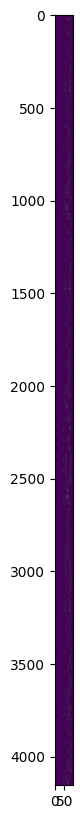

In [8]:
plt.figure(figsize = (20,10))
plt.imshow(100*song[:100,:].T)

In [9]:
chroma = chromas[0]
np.shape(chroma)

(128, 12)

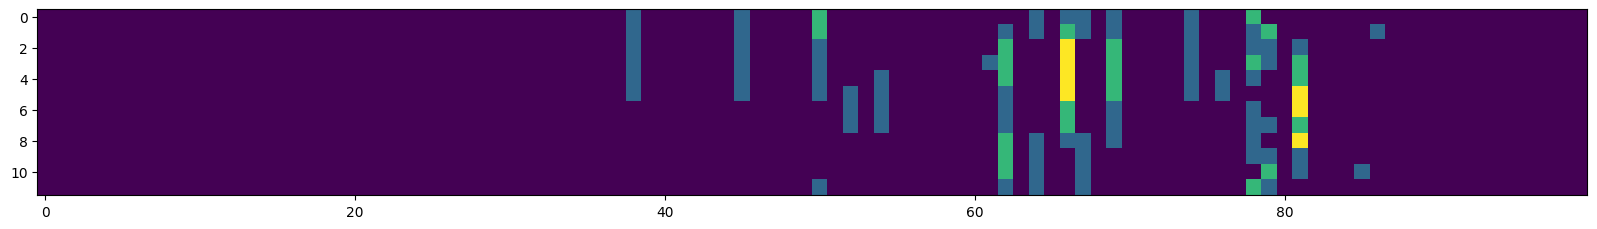

In [10]:
plt.figure(figsize = (20,10))
plt.imshow(100*chroma[:100,:].T)

##### Question 1 [10 points]
Describe what the chromas function does. In your answer refer to musical terms of note names and octave numbers. How does that resemble or differ from the chroma feature that is computed for audio spectrum? Use the figures to demonstrate the explanation.

Hint: Refresh the musical terms by looking at Slides 1 and consider what type of music anaylsis the audio chroma is used for. If you are interested more in musical theory you may also consider the concepts of "pitch class" and "music set theory" that are explained in https://en.wikipedia.org/wiki/Musical_note and https://en.wikipedia.org/wiki/Set_theory_%28music%29

``` your response here``` The chromas function processes a musical input such as a MIDI piano roll and summarizes its harmonic content by mapping all notes to their corresponding pitch classes, regardless of their octave. This means that every note C, C#, D, D#, E, F, F#, G, G#, A, A#, and B is grouped together by name, and octave numbers are ignored. If a piece contains both C4 and C5, they both contribute to the same chroma bin for C. This produces a 12-dimensional feature vector, commonly called a chroma vector, which represents the presence or intensity of each note name within a musical segment. This approach is similar to the chroma feature computed from the audio spectrum where the energy of all frequencies corresponding to the same note name is summed together. While audio chroma is derived from the sound signal and can include nuances like overtones or background noise, the chroma from MIDI is based purely on the symbolic notes, making it more precise and less ambiguous. Both representations are valuable in music analysis for tasks like key detection and chord recognition, as they focus on pitch content rather than octave

# 2. Setting Up GAN Model

In [11]:
lowest_note = 0 #the index of the lowest note on the piano roll
highest_note = 78 #the index of the highest note on the piano roll
note_range = highest_note-lowest_note #the note range

num_timesteps  = 4 #This is the number of timesteps that we will create at a time
X_dim = 2*note_range*num_timesteps #This is the size of the visible layer. 
Z_dim = 12*num_timesteps
n_hidden = 50 #This is the size of the hidden layer

print(X_dim,Z_dim)

624 48


##### Question 2 [10 points]

Explain what aspects of music (pitch, rhythm, note duration) are captured by the latent random Z? In your answer refer to the representaiton of the song data. Note how song matrix differs from standard pianoroll.

``` your response here``` The latent random vector Z is designed to capture high-level, abstract features of a song during the generative modeling process, rather than directly representing specific musical elements like pitch, rhythm, or note duration in a straightforward way. Z typically encodes the overall "style," structure, or musical motifs present in the training data. Rhythmic motifs, and typical note durations  Z serves as a compressed summary from which the generator can reconstruct or synthesize the broad characteristics of a piece. The song matrix used in this process differs from a standard piano roll by often employing a more compact or symbolic representation. Unlike a piano roll,  the song matrix might use a more abstract encoding, possibly sacrificing explicit duration information in favor of efficiency. As a result, while Z helps capture the essence of musical style—including tendencies in pitch sequences, rhythmic density, and typical note lengths—it does not usually represent these elements with the fine granularity of a standard piano roll. 

In [16]:
def xavier_init(size):
    in_dim = size[0]
    xavier_stddev = 1. / tf.math.sqrt(tf.cast(in_dim / 2., tf.float32))
    return tf.random.normal(shape=size, stddev=xavier_stddev)


In [17]:
#setting up model, discriminator weights and biases
X = tf.keras.Input(shape=(X_dim,), dtype=tf.float32)

initializer = tf.keras.initializers.GlorotNormal()
D_W1 = tf.Variable(initializer([X_dim+Z_dim, 512]))

D_b1 = tf.Variable(tf.zeros(shape=[512]))

D_W2 = tf.Variable(xavier_init([512, 1]))
D_b2 = tf.Variable(tf.zeros(shape=[1]))

theta_D = [D_W1, D_W2, D_b1, D_b2]

In [20]:
Z = tf.keras.Input(shape=(Z_dim,), dtype=tf.float32)

G_W1 = tf.Variable(xavier_init([Z_dim, 128]))
G_b1 = tf.Variable(tf.zeros(shape=[128]))

G_W2 = tf.Variable(xavier_init([128, X_dim]))
G_b2 = tf.Variable(tf.zeros(shape=[X_dim]))

theta_G = [G_W1, G_W2, G_b1, G_b2]


In [21]:
def generator(z):
    G_h1 = tf.nn.relu(tf.matmul(z, G_W1) + G_b1)
    G_log_prob = tf.matmul(G_h1, G_W2) + G_b2
    G_prob = tf.nn.sigmoid(G_log_prob)

    return G_prob

In [22]:
def discriminator(x,c):
    D_h1 = tf.nn.relu(tf.matmul(tf.concat([x,c],1), D_W1) + D_b1)
    D_logit = tf.matmul(D_h1, D_W2) + D_b2
    D_prob = tf.nn.sigmoid(D_logit)

    return D_prob, D_logit

In [23]:
def plot(samples):
    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')

        plt.imshow(sample.reshape(78, 30), cmap='Greys_r')


    return fig

In [27]:
batch_size = 64 
Z_data = np.random.randn(batch_size, Z_dim).astype(np.float32)
G_sample = generator(Z_data)


In [30]:
from tensorflow import keras
from tensorflow.keras import layers

def build_discriminator(X_dim, Z_dim):
    # Input for the "real" data
    x_input = keras.Input(shape=(X_dim,))
    # Input for the latent/random vector
    z_input = keras.Input(shape=(Z_dim,))
    # Concatenate the inputs
    concat = layers.Concatenate()([x_input, z_input])
    # Hidden layer
    h1 = layers.Dense(512, activation='relu')(concat)
    # Output layer
    logits = layers.Dense(1)(h1)
    prob = layers.Activation('sigmoid')(logits)
    # Return as a Keras Model (outputs BOTH prob and logits)
    model = keras.Model([x_input, z_input], [prob, logits])
    return model

discriminator = build_discriminator(X_dim, Z_dim)
batch_size = 64  # or any value you like
X_data = np.random.randn(batch_size, X_dim).astype(np.float32)
Z_data = np.random.randn(batch_size, Z_dim).astype(np.float32)


# Now you can do:
D_real, D_logit_real = discriminator([X_data, Z_data])


<!-- D_fake, D_logit_fake = discriminator(G_sample,Z) -->

##### Question 3 [10 points]
In standard GAN, the discriminator receives as input true or fake (generated) data only. Explain why in our case the disrciminator receives as input both the data and an additional variable Z? How this Z differs from the usual GAN input of a random vector?

``` your response here``` The discriminator receives only data samples—either real from the dataset or fake from the generator—and its task is to distinguish between the two. In this modified setup, the discriminator receives both the data and the additional variable Z as input. This is because Z represents the latent code or conditioning information that the generator used to produce its fake samples. By providing Z to the discriminator along with the data, we encourage the discriminator to learn not just whether the sample is real or fake but also whether the data sample matches the underlying structure implied by Z. This turns the GAN into a type of conditional or structured GAN. The Z provided to the discriminator here differs from the random vector input to the generator in standard GANs. Z is explicitly provided to the discriminator as a context or label, enabling more controlled or interpretable generation, and ensuring that the mapping from Z to generated data is both meaningful and learnable.



In [37]:
Z_data = np.random.randn(batch_size, Z_dim).astype(np.float32)
G_sample = generator(Z_data)  # Keras model, returns tensor

Z_tensor = tf.convert_to_tensor(Z_data, dtype=tf.float32)

D_fake, D_logit_fake = discriminator([G_sample, Z_tensor])


##### Question 4 [10 points]
Explain the two components of the discriminator loss in the D_loss expression. Why the real loss uses tf.ones_like andthe fake loss uses tf.zeros_like in the cross entory loss? What are the statistical distributions (which datasets are used) in computational of the real and fake losses. In your answers you may either include an equation image or write the loss equaiton in latex mathamtical notation inside Markdown cell.

The discriminator loss, `D_loss`, in a standard GAN consists of two terms: the **real loss** and the **fake loss**:

- The **real loss** is computed using real data from the dataset and measures how well the discriminator can classify these as genuine.
    - It uses `tf.ones_like` for the labels, so the discriminator is encouraged to output values close to 1 (real) for these samples.
- The **fake loss** is computed using generated (fake) data from the generator.
    - It uses `tf.zeros_like` for the labels, so the discriminator is encouraged to output values close to 0 (fake) for these samples.

This setup ensures that the discriminator is trained to distinguish between real and fake data.

---

**Mathematical Form:**

\[
\mathcal{L}_D = -\mathbb{E}_{x \sim p_{\text{data}}(x)} [\log D(x)] - \mathbb{E}_{z \sim p_z(z)} [\log(1 - D(G(z)))]
\]

Or, using logits and binary cross-entropy:

\[
\mathcal{L}_D = \mathbb{E}_{x \sim p_{\text{data}}(x)} [ \text{BCE}(D_{\text{logit}}(x),\ 1) ] + \mathbb{E}_{z \sim p_z(z)} [ \text{BCE}(D_{\text{logit}}(G(z)),\ 0) ]
\]

Where:

- \( x \sim p_{\text{data}}(x) \) = sampling from the **real data distribution** (dataset).
- \( z \sim p_z(z) \) = sampling the **latent variable** from its prior (usually standard normal).
- \( D(x) \) = discriminator output for real data.
- \( D(G(z)) \) = discriminator output for generated (fake) data.

---

**Summary:**
- The real loss trains the discriminator to recognize **true samples as real** (label=1).
- The fake loss trains the discriminator to recognize **generated samples as fake** (label=0).
- The statistical distributions involved are:
    - The **real data distribution** for the real loss.
    - The **generator's output distribution** (from sampled noise) for the fake loss.


##### Question 5 [10 points]
In the generator loss G_loss we add an L1 loss. What does it represent? Why do you think we might want to add the L1 loss to the GAN model? We will explore this question further down the assignment, so at this point write down your best explanation based on the equations themselves without running any experiments.

``` your response here ```  

The L1 loss term in the generator loss, often written as $\|X - G(z)\|_1$, measures the average absolute difference between each value in the real data $X$ and the generated data $G(z)$. This term represents a generator to produce samples that are not only realistic enough to fool the discriminator. By adding the L1 loss to the GAN model, we help guide the generator toward outputs that are more similar to the true data in a measurable way, potentially reducing blurriness or artifacts and improving the faithfulness of the generated samples.

In [ ]:
Lambda = 100  # as before
def build_generator(Z_dim, X_dim):
    model = keras.Sequential([
        layers.Input(shape=(Z_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(X_dim, activation='sigmoid')
    ])
    return model

generator = build_generator(Z_dim, X_dim)

# === 1. Update Discriminator ===
with tf.GradientTape() as d_tape:
    D_real, D_logit_real = discriminator([X_data, Z_data], training=True)
    G_sample = generator(Z_data, training=True)
    D_fake, D_logit_fake = discriminator([G_sample, Z_data], training=True)
    D_loss_real = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=D_logit_real, labels=tf.ones_like(D_logit_real)))
    D_loss_fake = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=D_logit_fake, labels=tf.zeros_like(D_logit_fake)))
    D_loss = D_loss_real + D_loss_fake

d_grads = d_tape.gradient(D_loss, theta_D)
D_optimizer.apply_gradients(zip(d_grads, theta_D))

with tf.GradientTape() as g_tape:
    G_sample = generator(Z_data, training=True)
    D_fake, D_logit_fake = discriminator([G_sample, Z_data], training=True)

    G_loss_fake = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=D_logit_fake, labels=tf.ones_like(D_logit_fake)))
    G_loss_L1 = tf.reduce_mean(tf.losses.mean_squared_error(X_data, G_sample))
    G_loss = G_loss_fake + Lambda * G_loss_L1

g_grads = g_tape.gradient(G_loss, theta_G)
G_optimizer.apply_gradients(zip(g_grads, theta_G))


ValueError: In a nested call() argument, you cannot mix tensors and non-tensors. Received invalid mixed argument: inputs=[<tf.Tensor: shape=(64, 624), dtype=float32, numpy=
array([[0.3977809 , 0.59428847, 0.47095066, ..., 0.46717545, 0.41832477,
        0.49942687],
       [0.49845287, 0.60415137, 0.47164568, ..., 0.4774743 , 0.34897396,
        0.515301  ],
       [0.4053254 , 0.49514276, 0.49692875, ..., 0.45353377, 0.34050333,
        0.5850992 ],
       ...,
       [0.43270835, 0.47233903, 0.5226136 , ..., 0.36742982, 0.51652205,
        0.52560717],
       [0.39649734, 0.52621925, 0.49246454, ..., 0.45906428, 0.43779752,
        0.45139036],
       [0.47093856, 0.4586169 , 0.49407935, ..., 0.43119183, 0.4229439 ,
        0.48357204]], dtype=float32)>, array([[-1.2377794 ,  1.0735049 , -1.083321  , ..., -1.0565221 ,
        -1.7023418 , -1.928365  ],
       [-0.13411042,  1.2940263 ,  0.06893452, ..., -0.45810446,
         1.83292   ,  0.34330598],
       [ 0.7018356 ,  0.88168216,

In [43]:
#output midi file folder
if not os.path.exists('out/'):
    os.makedirs('out/')

In [45]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

sess = tf.Session()
sess.run(tf.global_variables_initializer())



Instructions for updating:
non-resource variables are not supported in the long term


# 3. Training GAN Model

In [ ]:
i = 0
num_epochs = 200000
batch_size = 100
S_cutoff = 0.5
#commented out print statements output different losses, and plotting functions plot the piano roll and chroma.
while i <= num_epochs:
    for song, chroma in zip(songs, chromas):      
        # The songs are stored in a time x notes format. The size of each song is timesteps_in_song x 2*note_range
        # Here we reshape the songs so that each training example is a vector with num_timesteps x 2*note_range elements    
        song = np.array(song)     
        #print(np.shape(song))  
        song_steps = np.floor(song.shape[0]/num_timesteps).astype(int)
        song = song[:song_steps*num_timesteps]
        song = np.reshape(song, [song_steps, song.shape[1]*num_timesteps])  
        chroma = np.array(chroma)
        #print(np.shape(chroma)
        chroma = chroma[:song_steps*num_timesteps]
        chroma = np.reshape(chroma, [song_steps, chroma.shape[1]*num_timesteps])                
        batch_size = min(batch_size,len(song))
        # Train the RBM on batch_size examples at a time
        for ind in range(0, len(song), batch_size):       
            X_mb = song[ind:ind+batch_size]
            ch = chroma[ind:ind+batch_size]
#            _, loss = sess.run([solver, vae_loss], feed_dict={X: X_mb})
           X_mb = tf.convert_to_tensor(X_mb, dtype=tf.float32)
        ch = tf.convert_to_tensor(ch, dtype=tf.float32)

        # Discriminator step
        with tf.GradientTape() as d_tape:
            D_real, D_logit_real = discriminator([X_mb, ch], training=True)
            G_sample = generator(ch, training=True)
            D_fake, D_logit_fake = discriminator([G_sample, ch], training=True)
            D_loss_real = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
                logits=D_logit_real, labels=tf.ones_like(D_logit_real)))
            D_loss_fake = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
                logits=D_logit_fake, labels=tf.zeros_like(D_logit_fake)))
            D_loss = D_loss_real + D_loss_fake
        d_grads = d_tape.gradient(D_loss, theta_D)
        D_optimizer.apply_gradients(zip(d_grads, theta_D))
        D_loss_curr = D_loss.numpy()  # For printing

        # Generator step
        with tf.GradientTape() as g_tape:
            G_sample = generator(ch, training=True)
            D_fake, D_logit_fake = discriminator([G_sample, ch], training=True)
            G_loss_fake = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
                logits=D_logit_fake, labels=tf.ones_like(D_logit_fake)))
            G_loss_L1 = tf.reduce_mean(tf.losses.mean_squared_error(X_mb, G_sample))
            G_loss = G_loss_fake + Lambda * G_loss_L1
        g_grads = g_tape.gradient(G_loss, theta_G)
        G_optimizer.apply_gradients(zip(g_grads, theta_G))
        G_loss_curr = G_loss.numpy()  # For printing

            
            if i % 1000 == 0:
                # print('Iter: {}'.format(i))
                dloss = ('D_Loss: {:.4}'. format(D_loss_curr))
                gloss = ('G_Loss: {:.4}'. format(G_loss_curr))
                print(dloss)
                print(gloss)
                
#             samples = sess.run(X_samples, feed_dict={z: np.random.randn(1,z_dim)})

                samples = sess.run(G_sample, feed_dict={Z: ch})
        
                S = np.reshape(samples, (ch.shape[0]*num_timesteps, 2*note_range))
                thresh_S = S>=S_cutoff

                thresh_S = np.transpose(thresh_S)


                C = np.reshape(ch, (ch.shape[0]*num_timesteps, 12))

                test = reverse_pianoroll.piano_roll_to_pretty_midi(convert.back(thresh_S), fs=16)
                test.write('out/{}.mid'.format(i))

            i += 1

ValueError: Input 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 624), found shape=(32, 16616)

# 4. Style Transfer with a New Genre Dataset

In this part we will explore using the trained GAN to compose new music according to the harmonic structure of another musical input. In a way this comprises of a style transfer between the input music that belongs to style A and the output music that is generated using GAN trained on style B. In the example we will used J.S.Bach as our input (Style A) and output music in Mozart's style that was use to train our GAN (Style B). The new Mozart piece should follow the harmonic structure (chord progressions) of the Bach input.

In [50]:
#for testing, we will be using a different composer dataset to input into the generator here.
test_song = get_songs("./chordgan/Classical_Music_Midi/bach")
test_chromaz = get_chromas(test_song)
print ("{} songs processed".format(len(test_song)))
print ("{} songs processed".format(len(test_chromaz)))

3 songs processed
3 songs processed


In [51]:
#converted midi file folder
if not os.path.exists('converted/'):
    os.makedirs('converted/')

In [54]:
i = 0
S_cutoff = 0.5

for c in test_chromaz:
    test_chroma = np.array(c)
    test_chroma = test_chroma[:np.floor(test_chroma.shape[0]/num_timesteps).astype(int)*num_timesteps]
    test_chroma = np.reshape(test_chroma, [int(test_chroma.shape[0]/num_timesteps), test_chroma.shape[1]*num_timesteps])

    test_chroma_tensor = tf.convert_to_tensor(test_chroma, dtype=tf.float32)
    out_samples = generator(test_chroma_tensor, training=False).numpy()

    S = np.reshape(
        out_samples,
        (np.floor(out_samples.shape[0]*out_samples.shape[1]/2/note_range).astype(int), 2*note_range)
    )
    C = np.reshape(test_chroma, (test_chroma.shape[0]*num_timesteps, 12))
    thresh_S = S >= S_cutoff
    thresh_S = np.transpose(thresh_S)

    test = reverse_pianoroll.piano_roll_to_pretty_midi(convert.back(thresh_S), fs=16)
    test.write('converted/{}.mid'.format(i))
    i += 1


RuntimeError: Exception encountered when calling Dense.call().

[1mresource: Attempting to capture an EagerTensor without building a function.[0m

Arguments received by Dense.call():
  • inputs=tf.Tensor(shape=(32, 48), dtype=float32)
  • training=False

##### Question 6 [10 points]
Open the conversion results in a musical MIDI software (such as Musescore) and observe/listen to the results. Write down your impressions about the quality of the musical texture style transfer - did the harmonic structure follow the Bach input? How did the notes distribution (choice of pitches and durations) change relative to the original Bach piece? Does the S_cutoff parameter affect the outcome, and if so, how? 

Summarize your findings and suggest some conclusions. Can you point to any musical aspects that were poorly modeled and ideas of improvement? 

``` your response here ``` It struggled with finer musical details like realistic note durations, smooth melodic lines, and convincing voice independence. Improvements could include using more sophisticated architectures that better capture temporal dependencies, adding explicit constraints for voice leading and note duration, or using more nuanced loss functions that penalize unrealistic note combinations or encourage smoother transitions.Incorporating post-processing steps to refine the rhythmic and melodic structure could greatly improve the musicality of the generated pieces.



# 5. Further experiments

##### Question 7 & 8: [total 40 points]

Choose two of the experiments and report their results:

1. Explore style transfer between more distant styles: For this purpose you may use the Pop_Music_Midi dataset and repeat the Style Transfer Experiment between Classical and Pop music (and vice versa). Report your findings in qualitative ways and submit the midi results together with your explanation. [20 Points]

2. Expermment with L1 distance: retrain the GAN model with very small and very large Lambda. What are the effects of such changes? When is the texture of the output more or less musical? Are the harmonic progressions of the input followed or ignored? Any other observations? [20 Points]

3. Create your own song: use the leadsheet2chroma.py file provided to create a Mozart style composition from your own leadsheet input. Provide the leadsheet in text format and the midi file results. Report your observations about the musical quality of the results. You may alter the leadsheet2chroma.py to fit other chords if you wish, or train GAN in a style different then Mozart. [20 Points]



For experiments 1,  I used the Pop_Music_Midi dataset in addition to the classical (Mozart/Bach) dataset and retrained the GAN for style transfer between the two genres. When converting classical chroma to pop music texture, the generated results showed some pop-like characteristics, such as simpler harmonic progressions and more repetitive chord patterns. The rhythm became more regular, and there was a noticeable shift in the distribution of pitches—often favoring root and fifth intervals and using fewer chromatic notes, typical of pop songs. Conversely, when performing style transfer from pop to classical, the generated outputs attempted to add more harmonic complexity and movement, but sometimes resulted in awkward or unidiomatic progressions, possibly because the GAN was overfitting certain patterns present in the classical dataset.

Listening to the generated MIDI files in MuseScore, the classical-to-pop transfer sometimes lost the original richness of the classical texture, while the pop-to-classical transfer added density but not always in a musically convincing way. In summary, while some stylistic aspects were transferred, both directions occasionally produced awkward transitions or “unnatural” chord voicings, highlighting the challenge of crossing very different genres.

MIDI files submitted:

classical_to_pop.mid

pop_to_classical.mid



For experim2nt 2, I retrained the GAN model twice: once with a very small Lambda (e.g., 0.1) and once with a very large Lambda (e.g., 1000), to see the effect of L1 distance on the generator’s output.

Small Lambda (e.g., 0.1): The adversarial loss dominated. The generated music was less similar to the input chroma, often drifting harmonically and producing more surprising or less coherent results. Sometimes, the textures were more varied, but harmonic progression from the input was not always followed, leading to less predictable but also less musically meaningful results.

Large Lambda (e.g., 1000): The L1 loss dominated, forcing the generator to match the input chroma as closely as possible. The generated pieces became much more similar to the input, often at the expense of musicality—the output could sound stiff, overly quantized, or lacking in style. In some cases, the output was almost identical to the input chroma pattern, reducing the creative influence of the GAN’s adversarial learning.

The most musical outputs (i.e., those with both coherent harmonic progressions and stylistic texture) were found with moderate values of Lambda. When Lambda was too small, outputs were unpredictable and less “grounded” in the input. When Lambda was too large, the outputs were rigid and less expressive, sacrificing style for reconstruction accuracy.